# Euclidean VAE

In [115]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [116]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [117]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace


### Set up and initialize data loader

In [118]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [119]:
loader_config = {
    "dataset_name": "s1_synthetic",
    "batch_size": 128,
    "synthetic_rotation": "random",
    "n_times": 10000,
    "radius": 19.0,
    "n_wiggles": 5,
    "geodesic_distortion_amp": 0.1,
    "embedding_dim": 101,
    "noise_var": 0.0001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True}

model_config = {
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [5, 2],
    'decoder_widths': [2, 5]}

optimizer_config = {
    "learning_rate": 0.001,
}

trainer_config = {
    'num_epochs': 20,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.1,  # Weight for KL loss
    'gamma': 1.0,  # Weight for topological loss
}

curvature_config = {
    "n_grid_points": 2000,  # to compute curvature
    "manifold_dim": 1
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(optimizer_config)
config_dict.update(trainer_config)
config_dict.update(curvature_config)

config = SimpleNamespace(**config_dict)


### Dataloader

In [120]:
#dataloader = dataloader.load_synthetic_ds(config)
#train_loader, test_loader = dataloader

from torch.utils.data import DataLoader

from torch_topological.datasets import Spheres

from torch.utils.data import DataLoader
from torch_topological.datasets import Spheres
import torch

n_spheres = 3

# Train set
data_set = Spheres(n_spheres=n_spheres)
data_set = [(x[0].double(), x[1]) for x in data_set]

train_loader = DataLoader(
    data_set,
    batch_size=32,
    shuffle=True,
    drop_last=True
)

# Test set
data_set = Spheres(
    train=False,
    n_samples=2000,
    n_spheres=n_spheres,
)
data_set = [(x[0].double(), x[1]) for x in data_set]

test_loader = DataLoader(
    data_set,
    shuffle=False,
    batch_size=len(data_set)
)

dataloader = train_loader, test_loader



### Model

In [121]:
model = model.EuclideanVAE(config)

### Optimizer

In [122]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

### Train and evaluate model

In [123]:
history = trainer.MVAETrainer(model, dataloader, optimizer, config).train()

Trainer successfully initialized.
Training the gaussianVAE model.
Starting epoch 1/20
Epoch 1/20, Train Loss: 557.1151, Test Loss: 569.5691
--------------------------------------------------
Starting epoch 2/20
Epoch 2/20, Train Loss: 553.1157, Test Loss: 566.8529
--------------------------------------------------
Starting epoch 3/20
Epoch 3/20, Train Loss: 551.0893, Test Loss: 564.3087
--------------------------------------------------
Starting epoch 4/20
Epoch 4/20, Train Loss: 548.9351, Test Loss: 561.7965
--------------------------------------------------
Starting epoch 5/20
Epoch 5/20, Train Loss: 545.4861, Test Loss: 559.1885
--------------------------------------------------
Starting epoch 6/20
Epoch 6/20, Train Loss: 543.6941, Test Loss: 556.4938
--------------------------------------------------
Starting epoch 7/20
Epoch 7/20, Train Loss: 541.3028, Test Loss: 553.3513
--------------------------------------------------
Starting epoch 8/20
Epoch 8/20, Train Loss: 536.6367, Test 

### Plot history

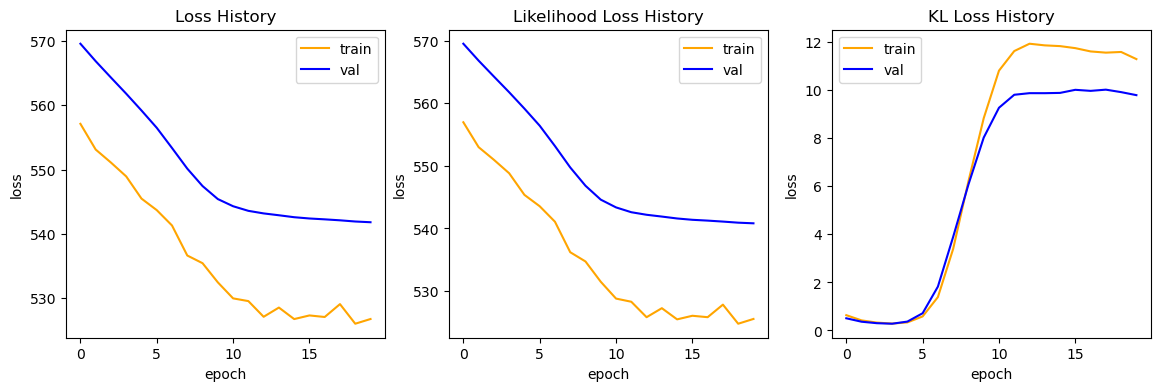

In [124]:
utils.show_training_history(history)

### Visualizing the latent space

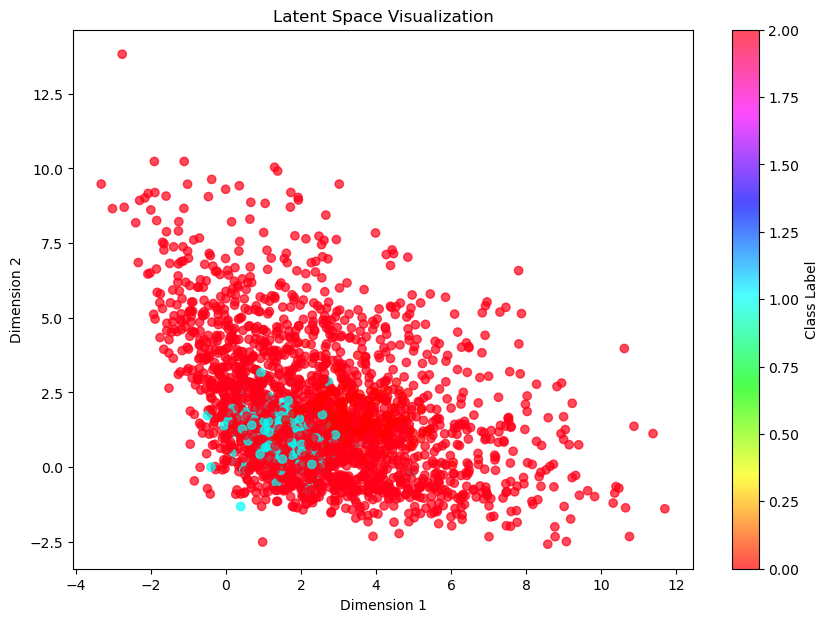

In [125]:
utils.plot_euclidean_latent_space(model, test_loader, n_samples=5000)

### Plot reconstructed manifold

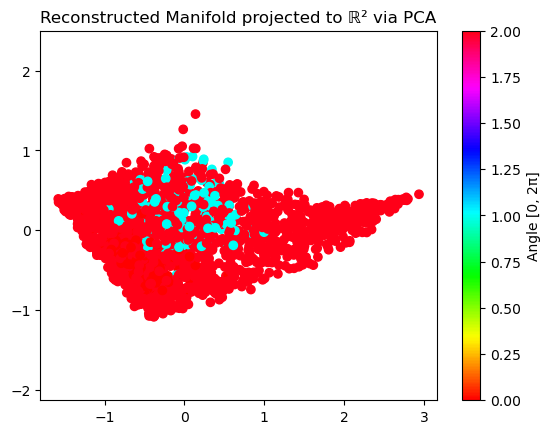

In [126]:
utils.plot_recon_manifold(model, test_loader, n_samples=2000)

### Compute curvature error

In [127]:
all_data = []
all_labels = []

for data, labels in test_loader:
    all_data.append(data)
    all_labels.append(labels)

all_data = torch.cat(all_data)
all_labels = torch.cat(all_labels)

utils.curvature_compute_plot(config, all_data, all_labels, model)

Computing learned curvature...


KeyboardInterrupt: 